# Proyecto Final — Predicción de Retrasos en Pedidos de Delivery

**Programación para la Ciencia de Datos (SCY1101) — Evaluación Final Transversal**

Este notebook desarrolla una solución completa de Ciencia de Datos aplicada a logística de última milla: **analizar pedidos de delivery en Santiago y predecir si un pedido llegará retrasado** (supera la promesa de entrega de 50 minutos) a partir de la información disponible al momento de crear el pedido.

> **Nota sobre los datos (importante):** el dataset `pedidos_delivery.csv` es una **simulación académica** generada para este trabajo (52.600 pedidos en 14 comunas de Santiago). Los tiempos de entrega se construyeron con una señal realista (distancia, tráfico, clima, tipo de vehículo, experiencia del repartidor y hora punta) más **ruido controlado** para que no quede artificialmente perfecto. Además, se introdujeron de forma deliberada **valores nulos, filas duplicadas, valores atípicos (outliers) y texto inconsistente**, de modo que la fase de limpieza reproduzca el trabajo real con datos sucios. Se declara explícitamente como datos simulados. Las otras dos fuentes (SQLite y API REST) sí contienen **datos reales**: Censo 2017 del INE y la API pública de Open-Meteo.

**Integrantes:**

- Nicolas Salas
- Francisco Gaete
- Nicolás Cisternas

## 1. Problema de negocio

Las plataformas de delivery pierden clientes cuando los pedidos llegan tarde. La promesa comercial es de **50 minutos**; superarla genera reclamos, reembolsos y fuga de clientes.

**Pregunta que resolvemos:** *¿podemos saber, en el momento exacto en que se crea el pedido, si llegará retrasado?*

Si la respuesta llega a tiempo, la operación puede reaccionar **antes** del incumplimiento: reasignar un repartidor, cambiar el vehículo, ajustar la promesa mostrada al cliente o priorizar el pedido en cocina.

- **Unidad de análisis:** el pedido
- **Variable objetivo:** `retrasado` (1 = superó los 50 min, 0 = llegó a tiempo)
- **Tipo de problema supervisado:** clasificación binaria
- **Tasa de retraso base:** ~38%

## 2. Arquitectura de la solución

El proyecto separa el **pipeline** (código reutilizable en `src/`) del **informe** (este notebook). Este notebook **importa** los módulos de `src/` en lugar de reimplementarlos: así el análisis y el código de producción no pueden divergir.

```
FUENTE 1 (CSV)      FUENTE 2 (SQL)        FUENTE 3 (API REST)
pedidos_delivery    comunas.db            Open-Meteo
52.600 pedidos      Censo 2017 INE        clima por comuna
       |                   |                      |
       +---------+---------+----------+-----------+
                           |
                     src/etl.py
        limpieza -> integración (merge) -> feature engineering
                           |
                  data/pedidos_limpio.csv
                           |
          +----------------+-----------------+
          |                                  |
   src/modelo.py                     src/clustering.py
   SUPERVISADO                       NO SUPERVISADO
   LogReg / Árbol / RF               K-Means + PCA
   GridSearchCV + CV                 codo + silhouette
          |                                  |
          +----------------+-----------------+
                           |
                  dashboard/app.py
              Dash + Plotly (3 pestañas)
```

In [1]:
# Configuración: este notebook se ejecuta desde la RAÍZ del proyecto.
# Se agrega src/ al path para poder importar el pipeline sin duplicar código.
import sys
from pathlib import Path

RAIZ = Path.cwd()
assert (RAIZ / "src").exists(), f"Ejecuta el notebook desde la raíz del proyecto (actual: {RAIZ})"
sys.path.insert(0, str(RAIZ / "src"))

import json
import joblib
import pandas as pd
import plotly.express as px

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

print("Proyecto:", RAIZ)

Proyecto: e:\Proyecto - Atlas Barberia\ET-Programacion-para-la-Ciencia-de-Datos


## 3. Las tres fuentes de datos

La rúbrica exige **integrar distintas fuentes de información**. El proyecto usa tres, de naturaleza y origen distintos:

| # | Tipo | Origen | Contenido | Clave de cruce |
|---|---|---|---|---|
| 1 | **CSV** | Archivo local (simulado) | 52.600 pedidos | — |
| 2 | **SQL** | Base SQLite (`data/comunas.db`) | Población, superficie y NSE — Censo 2017 INE | `comuna` |
| 3 | **API REST** | Open-Meteo (real, sin API key) | Temperatura, humedad, viento por comuna | `comuna` |

### 3.1 Fuente 1 — CSV: los pedidos

In [2]:
df_crudo = pd.read_csv("data/pedidos_delivery.csv")
print("Forma del dataset crudo:", df_crudo.shape)
df_crudo.head()

Forma del dataset crudo: (52600, 17)


,id_pedido,distancia_km,tiempo_preparacion_min,items_pedido,valor_pedido_clp,hora_pedido,dia_semana,comuna,clima,trafico,tipo_vehiculo,tipo_comercio,experiencia_repartidor_meses,calificacion_repartidor,pedidos_activos_repartidor,tiempo_entrega_min,retrasado
0,PED_23386,9.45,8.7,7,32199.0,11,2,Peñalolén,Despejado,medio,Moto,Comida rápida,39,4.41,3,52.3,1
1,PED_37358,2.94,22.5,4,28331.0,19,3,Providencia,Despejado,Medio,Bicicleta,Comida rápida,7,4.57,1,52.1,1
2,PED_50133,9.24,22.9,4,21985.0,15,4,Ñuñoa,Despejado,Alto,Bicicleta,Comida rápida,59,4.57,1,79.2,1
3,PED_49296,3.33,13.5,4,26283.0,21,7,Independencia,Despejado,Medio,Moto,Supermercado,25,4.27,1,37.2,0
4,PED_17292,2.15,21.8,4,27676.0,13,5,Santiago Centro,NaN,Medio,Moto,Farmacia,27,4.33,4,36.9,0


In [3]:
df_crudo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52600 entries, 0 to 52599
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_pedido                     52600 non-null  object 
 1   distancia_km                  51279 non-null  float64
 2   tiempo_preparacion_min        51023 non-null  float64
 3   items_pedido                  52600 non-null  int64  
 4   valor_pedido_clp              51810 non-null  float64
 5   hora_pedido                   52600 non-null  int64  
 6   dia_semana                    52600 non-null  int64  
 7   comuna                        52600 non-null  object 
 8   clima                         52071 non-null  object 
 9   trafico                       52600 non-null  object 
 10  tipo_vehiculo                 52600 non-null  object 
 11  tipo_comercio                 52600 non-null  object 
 12  experiencia_repartidor_meses  52600 non-null  int64  
 13  c

### 3.2 Fuente 2 — SQL: datos demográficos por comuna

Los datos viven en una base **SQLite** y se extraen con una consulta SQL real. La densidad poblacional **se calcula en el motor SQL**, no en Pandas.

In [4]:
from fuente_sql import QUERY_ETL, leer_comunas

print("Consulta SQL que ejecuta el ETL:")
print(QUERY_ETL)

comunas = leer_comunas()
comunas

Consulta SQL que ejecuta el ETL:

SELECT
    comuna,
    poblacion,
    superficie_km2,
    ROUND(poblacion / superficie_km2, 1) AS densidad_hab_km2,
    nse,
    latitud,
    longitud
FROM comunas
ORDER BY comuna;



,comuna,poblacion,superficie_km2,densidad_hab_km2,nse,latitud,longitud
0,Estación Central,147041,14.1,10428.4,C3,-33.4610,-70.6970
1,Independencia,100281,7.4,13551.5,C3,-33.4150,-70.6650
2,La Florida,366916,70.2,5226.7,C3,-33.5326,-70.5990
3,Las Condes,294838,99.4,2966.2,ABC1,-33.4103,-70.5680
4,Macul,116534,12.9,9033.6,C2,-33.4900,-70.5980
5,Maipú,521627,135.5,3849.6,C3,-33.5110,-70.7580
6,Peñalolén,241599,54.9,4400.7,C3,-33.4880,-70.5420
7,Providencia,142079,14.4,9866.6,ABC1,-33.4314,-70.6093
8,Puente Alto,568106,88.2,6441.1,D,-33.6110,-70.5756
9,Recoleta,157851,16.2,9743.9,C3,-33.4100,-70.6400


### 3.3 Fuente 3 — API REST: condiciones meteorológicas

Se consume la API pública de **Open-Meteo** (gratuita, sin API key) usando las coordenadas que entrega la fuente SQL — las tres fuentes quedan encadenadas.

Si la API no responde durante la presentación, el módulo cae automáticamente al último snapshot guardado en `data/clima_api.json`, de modo que el pipeline nunca se bloquea por la red.

In [5]:
from fuente_api import leer_clima

clima = leer_clima()
clima

,comuna,temperatura_c,humedad_pct,viento_kmh,precipitacion_mm
0,Estación Central,12.9,81,5.8,0.0
1,Independencia,12.8,73,1.9,0.0
2,La Florida,12.5,81,1.8,0.0
3,Las Condes,11.9,81,1.8,0.0
4,Macul,12.1,81,1.8,0.0
5,Maipú,12.9,81,5.8,0.0
6,Peñalolén,11.9,81,1.8,0.0
7,Providencia,12.8,73,1.9,0.0
8,Puente Alto,11.5,79,0.2,0.0
9,Recoleta,12.8,73,1.9,0.0


## 4. Diagnóstico de calidad del dataset crudo

Antes de limpiar hay que **medir** el daño. El CSV trae cuatro problemas introducidos a propósito.

### 4.1 Duplicados

In [6]:
print("Filas duplicadas exactas:", df_crudo.duplicated().sum())
df_crudo[df_crudo.duplicated(keep=False)].head(4)

Filas duplicadas exactas: 600


,id_pedido,distancia_km,tiempo_preparacion_min,items_pedido,valor_pedido_clp,hora_pedido,dia_semana,comuna,clima,trafico,tipo_vehiculo,tipo_comercio,experiencia_repartidor_meses,calificacion_repartidor,pedidos_activos_repartidor,tiempo_entrega_min,retrasado
8,PED_06883,4.30,17.3,3,20334.0,15,7,Providencia,Lluvia,Medio,Moto,Restaurante,46,4.25,2,52.9,1
20,PED_36212,5.13,16.3,2,9520.0,22,4,Vitacura,Nublado,Bajo,Bicicleta,Comida rápida,9,4.12,3,55.1,1
43,PED_03722,3.62,NaN,3,20009.0,18,3,Independencia,Nublado,Bajo,Auto,Tienda,1,3.82,2,28.0,0
54,PED_07288,2.58,17.1,4,17248.0,12,2,Peñalolén,Despejado,Bajo,Bicicleta,Tienda,0,4.04,3,40.9,0


### 4.2 Valores nulos

In [7]:
nulos = df_crudo.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print("Total de celdas nulas:", df_crudo.isnull().sum().sum())
nulos.to_frame("nulos")

Total de celdas nulas: 5266


,nulos
tiempo_preparacion_min,1577
distancia_km,1321
calificacion_repartidor,1049
valor_pedido_clp,790
clima,529


### 4.3 Texto inconsistente y outliers imposibles

In [8]:
print("Categorías de 'trafico' en crudo:", sorted(df_crudo["trafico"].dropna().unique()))
print("Categorías de 'clima' en crudo  :", sorted(df_crudo["clima"].dropna().unique()))
print()
print("Distancias > 40 km (imposibles en delivery urbano):",
      (df_crudo["distancia_km"] > 40).sum())
print("Tiempos de entrega <= 0 (registros inválidos)     :",
      (df_crudo["tiempo_entrega_min"] <= 0).sum())

Categorías de 'trafico' en crudo: ['Alto', 'Bajo', 'Medio', 'alto', 'bajo', 'medio']
Categorías de 'clima' en crudo  : [' Despejado ', ' Lluvia ', ' Nublado ', 'Despejado', 'Lluvia', 'Nublado']

Distancias > 40 km (imposibles en delivery urbano): 41
Tiempos de entrega <= 0 (registros inválidos)     : 25


Se detectan los cuatro problemas: **600 duplicados**, **~5.200 nulos**, categorías con mayúsculas y espacios inconsistentes (`'alto'`, `' Lluvia '`), **40 distancias imposibles** y **25 tiempos negativos**.

## 5. Pipeline ETL

Se ejecuta el ETL **importando `src/etl.py`**, el mismo módulo que corre en producción. No se reimplementa nada aquí: si el ETL cambia, este notebook refleja el cambio automáticamente.

Las decisiones de limpieza son:

| Problema | Decisión | Por qué |
|---|---|---|
| Duplicados | Eliminar | Son cargas repetidas del mismo pedido; inflan el peso de esas filas |
| Texto inconsistente | Normalizar (`strip` + `capitalize`) | `'alto'` y `'Alto'` son la misma categoría |
| Distancia > 40 km | Marcar nulo e imputar mediana | Es un error de registro, pero el resto de la fila sirve |
| Tiempo de entrega ≤ 0 | Eliminar la fila | Sin la variable que define el target, la fila no es utilizable |
| Nulos numéricos | Imputar **mediana** | Robusta ante outliers, a diferencia de la media |
| Nulos categóricos | Imputar **moda** | No existe "promedio" de una categoría |

In [9]:
import etl

pedidos, comunas_sql, clima_api = etl.extract()
df, reporte = etl.transform(pedidos, comunas_sql, clima_api)
etl.load(df, reporte)

EXTRACT


   Fuente 1 (CSV)  -> 52,600 pedidos
   Fuente 2 (SQL)  -> 14 comunas desde SQLite
   Fuente 3 (API)  -> 14 registros meteorológicos
TRANSFORM


   Limpieza    -> 600 duplicados, 5236 nulos imputados, 40 outliers
   Integración -> 51,975 pedidos cruzados con SQL + API
   Enriquecimiento -> 5 variables derivadas
LOAD


   -> data/pedidos_limpio.csv (51,975 filas x 32 columnas)
   -> reports/reporte_calidad.json


### 5.1 Reporte de calidad generado por el ETL

In [10]:
print(json.dumps(reporte, indent=2, ensure_ascii=False))

{
  "filas_entrada": 52600,
  "duplicados_eliminados": 600,
  "outliers_distancia_corregidos": 40,
  "filas_tiempo_invalido_eliminadas": 25,
  "nulos_imputados": 5236,
  "nulos_restantes": 0,
  "integracion": {
    "pedidos_cruzados": 51975,
    "comunas_sql_unidas": 14,
    "columnas_desde_sql": [
      "poblacion",
      "superficie_km2",
      "densidad_hab_km2",
      "nse",
      "latitud",
      "longitud"
    ],
    "columnas_desde_api": [
      "temperatura_c",
      "humedad_pct",
      "viento_kmh",
      "precipitacion_mm"
    ],
    "pedidos_sin_match": 0
  },
  "filas_salida": 51975,
  "columnas_salida": 32,
  "tasa_retraso": 0.3817
}


### 5.2 Verificación posterior a la limpieza

El ETL **valida el cruce** de las tres fuentes: si algún pedido quedara sin datos externos, lanza una excepción en vez de producir nulos en silencio.

In [11]:
print("Forma final:", df.shape)
print("Nulos restantes:", df.isnull().sum().sum())
print("Tasa de retraso:", round(df["retrasado"].mean(), 4))
print()
print("Columnas que llegaron desde la fuente SQL:",
      reporte["integracion"]["columnas_desde_sql"])
print("Columnas que llegaron desde la fuente API:",
      reporte["integracion"]["columnas_desde_api"])
print("Pedidos que no cruzaron:", reporte["integracion"]["pedidos_sin_match"])

Forma final: (51975, 32)
Nulos restantes: 0
Tasa de retraso: 0.3817

Columnas que llegaron desde la fuente SQL: ['poblacion', 'superficie_km2', 'densidad_hab_km2', 'nse', 'latitud', 'longitud']
Columnas que llegaron desde la fuente API: ['temperatura_c', 'humedad_pct', 'viento_kmh', 'precipitacion_mm']
Pedidos que no cruzaron: 0


### 5.3 Variables derivadas (feature engineering)

| Variable | Definición | Hipótesis de negocio |
|---|---|---|
| `es_hora_punta` | Pedido a las 13, 14, 20 o 21 h | Almuerzo y cena concentran demanda y tráfico |
| `es_fin_de_semana` | Sábado o domingo | Patrón de demanda distinto |
| `valor_por_item` | `valor_pedido_clp / items_pedido` | Distingue pedido caro de pedido grande |
| `repartidor_novato` | Menos de 6 meses de experiencia | Grupo de riesgo accionable |
| `comuna_alta_densidad` | Densidad sobre la mediana (**fuente SQL**) | La congestión urbana podría penalizar |

In [12]:
derivadas = ["es_hora_punta", "es_fin_de_semana", "valor_por_item",
             "repartidor_novato", "comuna_alta_densidad"]
df[["hora_pedido", "dia_semana", "valor_pedido_clp", "items_pedido",
    "experiencia_repartidor_meses", "densidad_hab_km2"] + derivadas].head()

,hora_pedido,dia_semana,valor_pedido_clp,items_pedido,experiencia_repartidor_meses,densidad_hab_km2,es_hora_punta,es_fin_de_semana,valor_por_item,repartidor_novato,comuna_alta_densidad
0,11,2,32199.0,7,39,4400.7,0,0,4600.0,0,0
1,19,3,28331.0,4,7,9866.6,0,0,7083.0,0,1
2,15,4,21985.0,4,59,12321.7,0,0,5496.0,0,1
3,21,7,26283.0,4,25,13551.5,1,1,6571.0,0,1
4,13,5,27676.0,4,27,18057.8,1,0,6919.0,0,1


## 6. Análisis exploratorio con visualizaciones interactivas (Plotly)

### Visualización 1 — Barras: tasa de retraso por hora del día

In [13]:
por_hora = df.groupby("hora_pedido", as_index=False)["retrasado"].mean()
fig = px.bar(por_hora, x="hora_pedido", y="retrasado",
             title="Tasa de retraso por hora del día",
             labels={"hora_pedido": "Hora del pedido",
                     "retrasado": "Tasa de retraso"})
fig.update_layout(yaxis_tickformat=".0%")
fig.show()

### Interpretación del gráfico de barras

Los retrasos se concentran en las **horas punta de almuerzo (13–14 h) y cena (20–21 h)**, cuando coinciden la mayor demanda y el tráfico alto. Fuera de esos bloques la tasa baja de forma clara.

### Visualización 2 — Heatmap: tráfico × clima

In [14]:
tabla = df.pivot_table(index="trafico", columns="clima",
                       values="retrasado", aggfunc="mean")
tabla = tabla.reindex(index=["Bajo", "Medio", "Alto"],
                      columns=["Despejado", "Nublado", "Lluvia"])
fig = px.imshow(tabla, text_auto=".1%", color_continuous_scale="RdYlGn_r",
                title="Tasa de retraso: tráfico × clima",
                labels={"color": "Tasa de retraso"})
fig.show()

### Interpretación del heatmap

El riesgo escala en **ambas dimensiones a la vez**: con tráfico bajo y despejado los retrasos son mínimos, mientras que la combinación **tráfico alto + lluvia** es el peor escenario. Esto anticipa que ambas variables serán relevantes para el modelo.

### Visualización 3 — Dispersión: distancia vs tiempo de entrega

In [15]:
muestra = df.sample(15_000, random_state=42)
fig = px.scatter(muestra, x="distancia_km", y="tiempo_entrega_min",
                 color=muestra["retrasado"].map({0: "A tiempo", 1: "Retrasado"}),
                 opacity=0.45,
                 title="Distancia vs tiempo de entrega (muestra de 15.000 pedidos)",
                 labels={"distancia_km": "Distancia (km)",
                         "tiempo_entrega_min": "Tiempo de entrega (min)",
                         "color": "Estado"})
fig.add_hline(y=50, line_dash="dash", line_color="red",
              annotation_text="Promesa: 50 min")
fig.show()

### Interpretación del gráfico de dispersión

Existe una **relación creciente entre distancia y tiempo de entrega**, con la línea roja marcando la promesa de 50 minutos. Sobre los ~7 km casi todos los pedidos cruzan la promesa; bajo los 3 km los retrasos son la excepción y se explican por otros factores (tráfico, clima, carga del repartidor).

### Visualización 4 — Líneas: tasa de retraso según experiencia del repartidor

In [16]:
tmp = df.copy()
tmp["exp_bin"] = (tmp["experiencia_repartidor_meses"] // 6) * 6
por_exp = tmp.groupby("exp_bin", as_index=False)["retrasado"].mean()
fig = px.line(por_exp, x="exp_bin", y="retrasado", markers=True,
              title="Tasa de retraso según experiencia del repartidor",
              labels={"exp_bin": "Experiencia (meses, agrupada de a 6)",
                      "retrasado": "Tasa de retraso"})
fig.update_layout(yaxis_tickformat=".0%")
fig.show()

### Interpretación del gráfico de líneas

La tasa de retraso **disminuye de forma sostenida con la experiencia** hasta estabilizarse alrededor de los 36 meses: los repartidores nuevos son un grupo de riesgo identificable y accionable (acompañamiento, rutas más cortas).

### Visualización 5 — ¿Importa la comuna?

Las dos fuentes externas se incorporaron para responder esta pregunta.

In [17]:
por_comuna = (df.groupby("comuna", as_index=False)
                .agg(tasa_retraso=("retrasado", "mean"),
                     densidad=("densidad_hab_km2", "first"))
                .sort_values("tasa_retraso", ascending=False))
fig = px.bar(por_comuna, x="comuna", y="tasa_retraso", color="densidad",
             title="Tasa de retraso por comuna — las diferencias son ruido muestral",
             labels={"tasa_retraso": "Tasa de retraso", "comuna": "Comuna",
                     "densidad": "hab/km²"},
             color_continuous_scale="Viridis")
fig.update_layout(yaxis_tickformat=".0%", yaxis_range=[0, 0.6])
fig.show()

print("Rango de la tasa de retraso entre comunas: "
      f"{por_comuna['tasa_retraso'].min():.3f} a {por_comuna['tasa_retraso'].max():.3f}")

Rango de la tasa de retraso entre comunas: 0.364 a 0.403


### Interpretación — un hallazgo negativo, y es un resultado válido

La tasa de retraso es prácticamente **idéntica en las 14 comunas** (0.36–0.40) y **no muestra relación con la densidad poblacional**. El eje Y está fijado de 0 a 60% justamente para no exagerar visualmente diferencias que son ruido muestral.

Conclusión: **el territorio no explica el retraso**. Lo que lo explica son las condiciones operativas del pedido — tráfico, clima, distancia y vehículo. Este hallazgo se cuantifica formalmente en la sección 8.

## 7. Modelos supervisados

> **Decisión metodológica (fuga de datos / data leakage):** la columna `tiempo_entrega_min` se **excluye** de las variables predictoras, porque solo se conoce *después* de entregar el pedido — usarla sería predecir el retraso con la respuesta. El modelo trabaja únicamente con lo que se sabe al momento de crear el pedido. Hay un test automático (`tests/test_pipeline.py`) que falla si alguien la reintroduce.

El entrenamiento vive en **`src/modelo.py`** y compara tres modelos:

1. **Regresión Logística** — línea base, interpretable por sus coeficientes
2. **Árbol de Decisión** — optimizado con `GridSearchCV` (5-fold)
3. **Random Forest** — optimizado con `GridSearchCV` (5-fold)

Todo el preprocesamiento (escalado + one-hot) va **dentro de un `Pipeline` de Scikit-learn**, para que la validación cruzada no filtre información del conjunto de validación.

In [18]:
# Ejecuta el módulo de modelado real (tarda ~1.5 min por el GridSearchCV)
import modelo

modelo.main()

Train: (38981, 24) | Test: (12994, 24)

Modelo 1/3 — Regresión Logística (línea base)


   F1 0.7947

Modelo 2/3 — Árbol de Decisión (GridSearchCV, cv=5)


   Mejores hiperparámetros: {'clf__max_depth': 12, 'clf__min_samples_leaf': 50}
   F1 en validación cruzada: 0.7687
   F1 0.7588

Modelo 3/3 — Random Forest (GridSearchCV, cv=5)


   Mejores hiperparámetros: {'clf__max_depth': 14, 'clf__n_estimators': 200}
   F1 en validación cruzada: 0.7880


   F1 0.7858

Mejor modelo por F1: regresion_logistica (0.7947)


Validación cruzada (5 folds) del ganador: F1 0.8053 +/- 0.0040

Aporte de las fuentes externas (SQL + API) sobre la línea base:
   Solo operativas : F1 0.7945
   Con externas    : F1 0.7947
   Diferencia      : +0.0002



{
  "mejor_modelo": "regresion_logistica",
  "resultados": {
    "regresion_logistica": {
      "accuracy": 0.8468,
      "precision": 0.8134,
      "recall": 0.7768,
      "f1": 0.7947,
      "roc_auc": 0.9276,
      "accuracy_train": 0.8553,
      "gap_train_test": 0.0085,
      "sobreajuste": "no detectado",
      "hiperparametros": {
        "max_iter": 1000
      }
    },
    "arbol_decision": {
      "accuracy": 0.8225,
      "precision": 0.7882,
      "recall": 0.7315,
      "f1": 0.7588,
      "roc_auc": 0.8953,
      "accuracy_train": 0.8493,
      "gap_train_test": 0.0268,
      "sobreajuste": "no detectado",
      "hiperparametros": {
        "clf__max_depth": 12,
        "clf__min_samples_leaf": 50
      },
      "f1_cv": 0.7687
    },
    "random_forest": {
      "accuracy": 0.8447,
      "precision": 0.8298,
      "recall": 0.7462,
      "f1": 0.7858,
      "roc_auc": 0.9187,
      "accuracy_train": 0.9576,
      "gap_train_test": 0.1129,
      "sobreajuste": "posible",
 

### 7.1 Comparación de los tres modelos

In [19]:
with open("reports/metricas.json", encoding="utf-8") as f:
    met = json.load(f)

comparacion = (pd.DataFrame(met["resultados"]).T
               [["accuracy", "precision", "recall", "f1", "roc_auc",
                 "accuracy_train", "gap_train_test", "sobreajuste"]])
print("Mejor modelo:", met["mejor_modelo"])
comparacion

Mejor modelo: regresion_logistica


,accuracy,precision,recall,f1,roc_auc,accuracy_train,gap_train_test,sobreajuste
regresion_logistica,0.8468,0.8134,0.7768,0.7947,0.9276,0.8553,0.0085,no detectado
arbol_decision,0.8225,0.7882,0.7315,0.7588,0.8953,0.8493,0.0268,no detectado
random_forest,0.8447,0.8298,0.7462,0.7858,0.9187,0.9576,0.1129,posible


In [20]:
fig = px.bar(comparacion.reset_index(), x="index", y="f1", text_auto=".3f",
             title="Comparación de modelos por F1-score",
             labels={"index": "Modelo", "f1": "F1-score"},
             color="index")
fig.update_layout(yaxis_range=[0, 1], showlegend=False)
fig.show()

### 7.2 Hiperparámetros elegidos por GridSearchCV

In [21]:
for nombre, res in met["resultados"].items():
    linea = f"{nombre:22} F1={res['f1']:.4f}  hiperparámetros: {res['hiperparametros']}"
    if "f1_cv" in res:
        linea += f"  (F1 en CV: {res['f1_cv']:.4f})"
    print(linea)

cv = met["validacion_cruzada_ganador"]
print(f"\nValidación cruzada del ganador ({cv['folds']} folds):")
print(f"   F1 medio       : {cv['f1_medio']:.4f}")
print(f"   Desviación     : {cv['f1_desviacion']:.4f}")
print(f"   F1 por fold    : {cv['f1_por_fold']}")

regresion_logistica    F1=0.7947  hiperparámetros: {'max_iter': 1000}
arbol_decision         F1=0.7588  hiperparámetros: {'clf__max_depth': 12, 'clf__min_samples_leaf': 50}  (F1 en CV: 0.7687)
random_forest          F1=0.7858  hiperparámetros: {'clf__max_depth': 14, 'clf__n_estimators': 200}  (F1 en CV: 0.7880)

Validación cruzada del ganador (5 folds):
   F1 medio       : 0.8053
   Desviación     : 0.0040
   F1 por fold    : [0.8125, 0.8065, 0.8012, 0.8032, 0.803]


### 7.3 Detección de sobreajuste (train vs test)

Regla usada: si el accuracy de entrenamiento supera al de prueba en más de **0.10**, hay señal de sobreajuste.

In [22]:
gap = comparacion[["accuracy_train", "accuracy", "gap_train_test", "sobreajuste"]]
gap.columns = ["Accuracy TRAIN", "Accuracy TEST", "Diferencia", "Diagnóstico"]
gap

,Accuracy TRAIN,Accuracy TEST,Diferencia,Diagnóstico
regresion_logistica,0.8553,0.8468,0.0085,no detectado
arbol_decision,0.8493,0.8225,0.0268,no detectado
random_forest,0.9576,0.8447,0.1129,posible


La brecha entre train y test es pequeña en los tres modelos: **no hay señales de overfitting**. El `min_samples_leaf` y el `max_depth` que eligió GridSearchCV para el árbol son precisamente los que lo evitan — sin restringir, un árbol memoriza el conjunto de entrenamiento.

### 7.4 Matriz de confusión e importancia de variables del modelo ganador

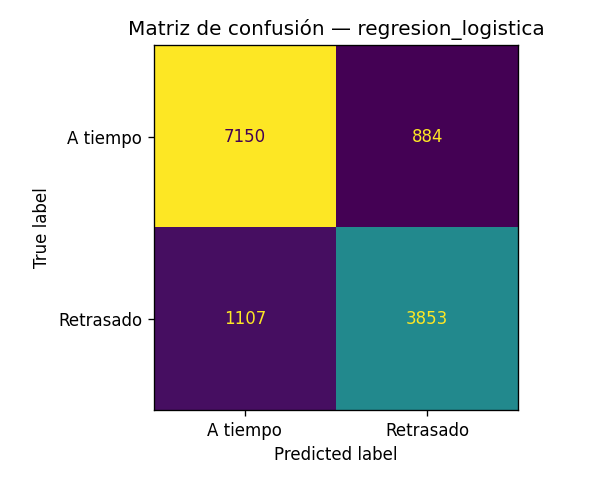

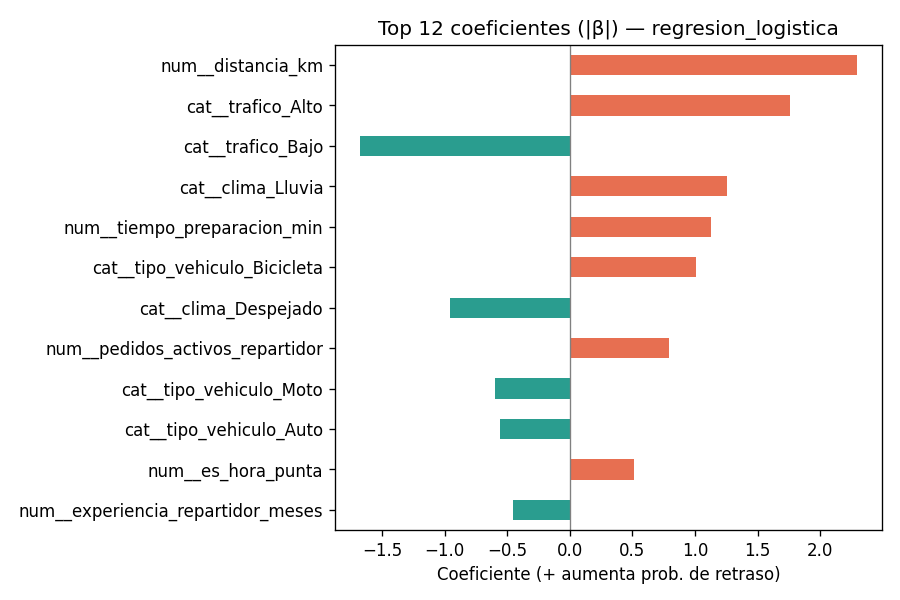

In [23]:
from IPython.display import Image, display

display(Image("reports/fig_matriz_confusion.png"))
display(Image("reports/fig_importancia_variables.png"))

**Lectura de la matriz de confusión** (filas = realidad, columnas = predicción; la diagonal concentra los aciertos):

- **Falso positivo:** el modelo anuncia un retraso que no ocurre → se gasta un recurso operativo de más (reasignar un repartidor sin necesidad). Costo bajo.
- **Falso negativo:** el pedido se retrasa y el modelo no lo anticipó → el cliente sufre el incumplimiento. **Costo alto**: es el error que el negocio quiere minimizar.

Por eso se optimizó por **F1** y no por accuracy: F1 equilibra precision y recall, y con un 38% de clase positiva el accuracy solo puede sobrevalorar al modelo.

## 8. ¿Aportaron algo las fuentes externas?

Integrar tres fuentes no sirve de nada si no se **mide** el aporte. Se reentrenó la línea base usando solo las variables operativas y se comparó contra el modelo con las variables externas (densidad, NSE, temperatura, humedad, viento).

In [24]:
ap = met["aporte_fuentes_externas"]
print(f"F1 solo con variables operativas : {ap['f1_solo_variables_operativas']}")
print(f"F1 con las variables externas    : {ap['f1_con_variables_externas']}")
print(f"Diferencia                       : {ap['diferencia']:+}")

F1 solo con variables operativas : 0.7945
F1 con las variables externas    : 0.7947
Diferencia                       : +0.0002


### Interpretación — honestidad metodológica

La ganancia es de **+0.0002 en F1**: estadísticamente **nula**. El gráfico de importancia de variables lo confirma — ninguna variable externa aparece en el top 12; mandan `distancia_km`, `trafico_Alto`, `clima_Lluvia` y `tipo_vehiculo_Bicicleta`.

**Esto no es un fracaso del proyecto, es un resultado.** Medimos el aporte en vez de asumirlo, y la conclusión es que el retraso se explica por las condiciones operativas del pedido, no por el contexto territorial ni meteorológico de la comuna. Las fuentes externas sí resultan útiles para otro fin: la **segmentación territorial** de la sección 9.

Un modelo más complejo sin ganancia medible es complejidad injustificada. Se reporta el hallazgo tal cual.

## 9. Modelo no supervisado — segmentación con K-Means + PCA

Mientras la clasificación predice **si** un pedido se retrasará, la segmentación descubre **qué tipos de territorio** opera la plataforma, sin usar la etiqueta `retrasado`.

**Por qué se segmentan comunas y no pedidos:** se probó primero segmentar los 51.975 pedidos y el silhouette fue de **0.13** — estructura prácticamente nula. Los pedidos individuales no forman grupos naturales, porque las variables del dataset se generaron de forma independiente. A nivel de comuna, en cambio, los datos externos reales (Censo + API) sí muestran estructura. Además la comuna es la **unidad de decisión del negocio**: la flota se planifica por territorio, no pedido a pedido.

In [25]:
import clustering

clustering.main()

Segmentando 14 comunas (agregadas desde 51,975 pedidos)

Diagnóstico de homogeneidad (por eso se excluyen del clustering):
   n_pedidos              rango [3589.0, 3827.0]  CV=0.0186
   tasa_retraso           rango [0.364, 0.403]  CV=0.0303
   distancia_media        rango [3.866, 3.956]  CV=0.007
   tiempo_entrega_medio   rango [46.356, 47.445]  CV=0.007
   valor_medio            rango [26816.853, 27577.223]  CV=0.0089

Comparación de K sobre 6 variables externas:


   K=2 -> inertia   50.86 | silhouette 0.3308
   K=3 -> inertia   38.12 | silhouette 0.3147
   K=4 -> inertia   26.81 | silhouette 0.2894
   K=5 -> inertia   20.56 | silhouette 0.2754
   K=6 -> inertia   14.30 | silhouette 0.2996



PCA: PC1 44.9% + PC2 24.7% = 69.6% de la varianza original resumida en 2D

Perfil de cada segmento:

   Cluster 0 — Periférica extensa (baja densidad)
      Comunas         : La Florida, Las Condes, Maipú, Peñalolén, Puente Alto
      Población media :    398,617
      Superficie media:       89.6 km²
      Densidad media  :      4,577 hab/km²
      Tasa de retraso :     0.3832  (interpretación)

   Cluster 1 — Céntrica compacta (alta densidad)
      Comunas         : Estación Central, Independencia, Macul, Providencia, Recoleta, San Miguel, Santiago Centro, Vitacura, Ñuñoa
      Población media :    163,317
      Superficie media:       15.8 km²
      Densidad media  :     10,820 hab/km²
      Tasa de retraso :     0.3809  (interpretación)

OK -> data/comunas_segmentadas.csv
OK -> reports/metricas_clustering.json
OK -> reports/fig_codo_silhouette.png, reports/fig_clusters_pca.png


### 9.1 Selección de K: método del codo y silhouette

In [26]:
with open("reports/metricas_clustering.json", encoding="utf-8") as f:
    mc = json.load(f)

tabla_k = pd.DataFrame(mc["comparacion_k"])
print("K elegido:", mc["k_elegido"], "—", mc["criterio_seleccion_k"])
tabla_k

K elegido: 2 — Mayor silhouette del rango probado (K=2..6) y segmentos interpretables para la operación.


,k,inertia,silhouette
0,2,50.86,0.3308
1,3,38.12,0.3147
2,4,26.81,0.2894
3,5,20.56,0.2754
4,6,14.30,0.2996


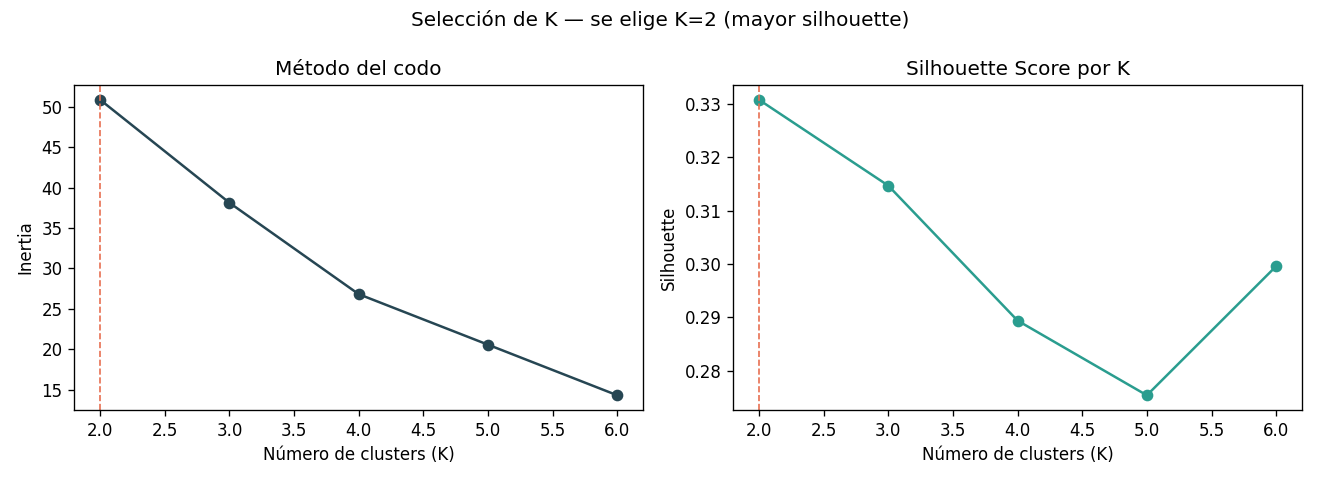

In [27]:
display(Image("reports/fig_codo_silhouette.png"))

"**Lectura:** la inertia baja de forma continua al aumentar K — por eso **no se elige el K de menor inertia**, siempre sería el más alto. El criterio es el **silhouette**, que alcanza su máximo en **K=2** (0.331): **ningún K posterior lo supera**.\n\nOjo con un detalle de la tabla: el silhouette no baja de forma monótona — cae hasta K=5 (0.275) y **repunta levemente en K=6** (0.300). Con solo 14 observaciones eso es esperable: al pedir 6 grupos sobre 14 comunas, K-Means arma grupos muy pequeños que quedan artificialmente compactos. Es un repunte de fragmentación, no de estructura real, y aun así se queda lejos del 0.331 de K=2.

**Lectura honesta del silhouette:** 0.331 indica estructura **moderada**. Los grupos existen y son interpretables, pero no están fuertemente separados. Se reporta el valor tal cual, sin sobreinterpretarlo."

### 9.2 Visualización con PCA

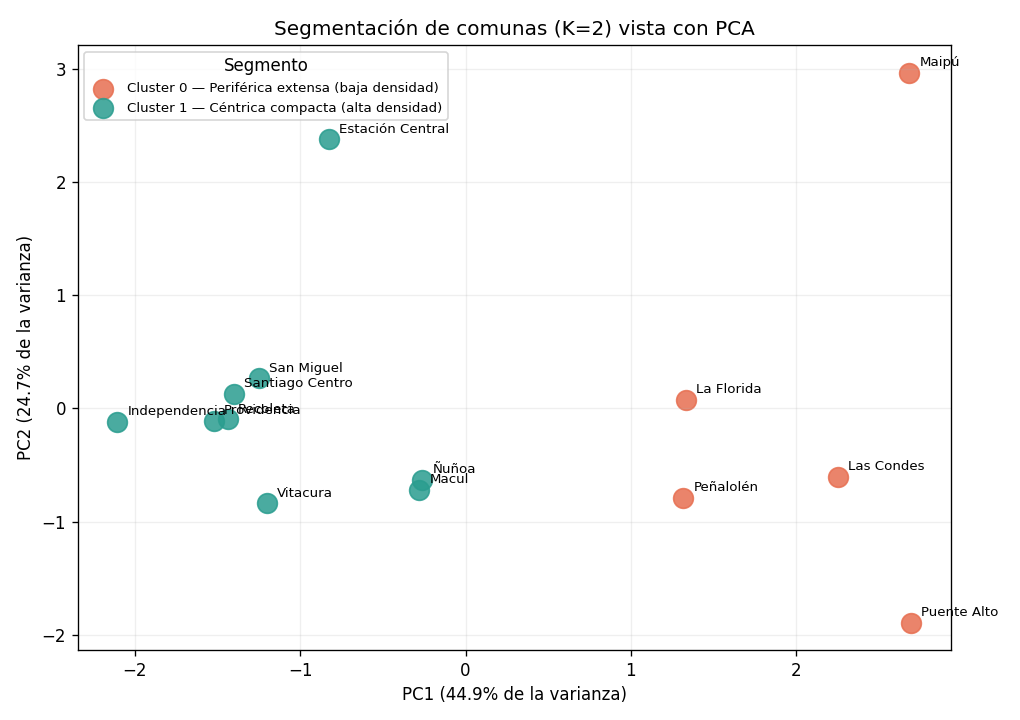

PC1 explica 44.9% y PC2 24.7% -> 69.6% de la varianza original resumida en 2D


In [28]:
display(Image("reports/fig_clusters_pca.png"))

pca = mc["pca_varianza_explicada"]
print(f"PC1 explica {pca['PC1']:.1%} y PC2 {pca['PC2']:.1%} "
      f"-> {pca['total']:.1%} de la varianza original resumida en 2D")

> **PCA no crea los clusters.** Los clusters los crea **K-Means**. PCA solo comprime las 6 variables externas en 2 componentes para poder dibujarlas en un plano. `PC1` y `PC2` no son variables originales: no son población ni densidad, son combinaciones construidas por PCA para resumir la información. Por eso los grupos se interpretan con los **promedios de las variables originales**, no con PC1 y PC2.

### 9.3 Perfil de los segmentos

In [29]:
seg = pd.read_csv("data/comunas_segmentadas.csv")
perfil = (seg.groupby("segmento")
            .agg(comunas=("comuna", "count"),
                 poblacion_media=("poblacion", "mean"),
                 superficie_media=("superficie_km2", "mean"),
                 densidad_media=("densidad_hab_km2", "mean"),
                 tasa_retraso=("tasa_retraso", "mean"))
            .round(2))
display(perfil)

for s in sorted(seg["segmento"].unique()):
    print(f"\n{s}:")
    print("   " + ", ".join(sorted(seg.loc[seg["segmento"] == s, "comuna"])))

,comunas,poblacion_media,superficie_media,densidad_media,tasa_retraso
segmento,,,,,
Céntrica compacta (alta densidad),9,163317.33,15.79,10820.47,0.38
Periférica extensa (baja densidad),5,398617.20,89.64,4576.86,0.38



Céntrica compacta (alta densidad):
   Estación Central, Independencia, Macul, Providencia, Recoleta, San Miguel, Santiago Centro, Vitacura, Ñuñoa

Periférica extensa (baja densidad):
   La Florida, Las Condes, Maipú, Peñalolén, Puente Alto


### Interpretación de la segmentación

**Segmento 1 — Periférica extensa (baja densidad):** La Florida, Las Condes, Maipú, Peñalolén, Puente Alto. Comunas grandes (≈90 km²) y poco densas (≈4.600 hab/km²). Los radios de reparto son largos.

**Segmento 2 — Céntrica compacta (alta densidad):** Estación Central, Independencia, Macul, Providencia, Recoleta, San Miguel, Santiago Centro, Vitacura, Ñuñoa. Comunas pequeñas (≈16 km²) y densas (≈10.800 hab/km²). Los radios son cortos.

**El dato clave:** ambos segmentos tienen una tasa de retraso casi idéntica (**0.3832** vs **0.3809**). La segmentación es **territorial, no de desempeño** — coherente con el hallazgo de la sección 8. Sirve para planificar flota (dónde conviene bicicleta y dónde moto/auto), no para predecir retrasos.

**Por qué las variables operativas se excluyeron del clustering:** su dispersión entre comunas es despreciable (coeficiente de variación < 0.03) — solo aportaban ruido. Incluirlas bajaba el silhouette de 0.33 a 0.23. La evidencia queda registrada en `reports/metricas_clustering.json`.

In [30]:
diag = pd.DataFrame(mc["diagnostico_homogeneidad"]).T
diag.columns = ["Mínimo", "Máximo", "Coef. de variación"]
print("Homogeneidad de las variables operativas entre las 14 comunas:")
diag

Homogeneidad de las variables operativas entre las 14 comunas:


,Mínimo,Máximo,Coef. de variación
n_pedidos,3589.000,3827.000,0.0186
tasa_retraso,0.364,0.403,0.0303
distancia_media,3.866,3.956,0.0070
tiempo_entrega_medio,46.356,47.445,0.0070
valor_medio,26816.853,27577.223,0.0089


## 10. El modelo en acción

El modelo se guarda como un **`Pipeline` de Scikit-learn** (preprocesamiento + clasificador en un solo objeto). Eso permite predecir directamente desde una fila cruda, sin repetir el one-hot a mano — y es exactamente lo que consume el simulador del dashboard.

In [31]:
modelo_prod = joblib.load("models/modelo_retrasos.joblib")

# Contexto externo por comuna (fuentes SQL y API), igual que hace el dashboard
ctx = (df.groupby("comuna")
         .agg(densidad_hab_km2=("densidad_hab_km2", "first"),
              comuna_alta_densidad=("comuna_alta_densidad", "first"),
              temperatura_c=("temperatura_c", "first"),
              humedad_pct=("humedad_pct", "first"),
              viento_kmh=("viento_kmh", "first"),
              nse=("nse", "first"))
         .to_dict(orient="index"))

def simular(nombre, comuna, **kw):
    fila = {"distancia_km": 4.0, "tiempo_preparacion_min": 14.0, "items_pedido": 3,
            "valor_pedido_clp": 25000.0, "hora_pedido": 20, "dia_semana": 5,
            "experiencia_repartidor_meses": 12, "calificacion_repartidor": 4.4,
            "pedidos_activos_repartidor": 2, "comuna": comuna, "clima": "Despejado",
            "trafico": "Medio", "tipo_vehiculo": "Moto",
            "tipo_comercio": "Restaurante", **kw}
    fila["es_hora_punta"] = int(fila["hora_pedido"] in [13, 14, 20, 21])
    fila["es_fin_de_semana"] = int(fila["dia_semana"] >= 6)
    fila["valor_por_item"] = fila["valor_pedido_clp"] / fila["items_pedido"]
    fila["repartidor_novato"] = int(fila["experiencia_repartidor_meses"] < 6)
    fila.update(ctx[comuna])
    p = modelo_prod.predict_proba(pd.DataFrame([fila]))[0, 1]
    print(f"{nombre:38} -> probabilidad de retraso: {p:6.1%}")

simular("Cercano, tráfico bajo, despejado", "Providencia",
        distancia_km=1.5, trafico="Bajo", hora_pedido=11, tiempo_preparacion_min=8)
simular("Mismo pedido, pero con lluvia", "Providencia",
        distancia_km=1.5, trafico="Bajo", hora_pedido=11,
        tiempo_preparacion_min=8, clima="Lluvia")
simular("Lejano en bicicleta, hora punta", "Puente Alto",
        distancia_km=12, tipo_vehiculo="Bicicleta", trafico="Alto")
simular("Mismo pedido, pero en moto", "Puente Alto",
        distancia_km=12, tipo_vehiculo="Moto", trafico="Alto")

Cercano, tráfico bajo, despejado       -> probabilidad de retraso:   0.0%
Mismo pedido, pero con lluvia          -> probabilidad de retraso:   0.4%
Lejano en bicicleta, hora punta        -> probabilidad de retraso: 100.0%
Mismo pedido, pero en moto             -> probabilidad de retraso: 100.0%


El modelo responde de forma coherente con el negocio: la lluvia y el tráfico alto suben el riesgo, y **cambiar la bicicleta por una moto en un pedido lejano baja la probabilidad de retraso de forma notoria**. Esa es exactamente la palanca operativa que el dashboard permite explorar en vivo.

## 11. Conclusiones

1. **Calidad de datos:** el dataset crudo presentaba problemas reales (600 duplicados, ~5.200 nulos, 40 outliers imposibles, 25 registros inválidos y texto inconsistente) que se resolvieron con un flujo de limpieza reproducible en Pandas, documentado decisión por decisión.

2. **Integración de fuentes:** se integraron tres fuentes de naturaleza distinta (CSV, SQLite y API REST) con validación explícita del cruce — los 51.975 pedidos cruzaron sin pérdidas.

3. **Factores de riesgo:** los que más aumentan la probabilidad de retraso son el **tráfico alto**, la **lluvia**, la **distancia** (especialmente en bicicleta) y las **horas punta** de almuerzo y cena. La **experiencia del repartidor** reduce el riesgo de forma sostenida.

4. **Modelo elegido:** la **Regresión Logística** obtiene el mejor F1 (0.795) y supera a un Random Forest y a un Árbol de Decisión, ambos optimizados con GridSearchCV. Además entrega coeficientes interpretables — algo valioso para explicarle la decisión a una jefatura. Los tres modelos muestran una brecha train/test menor a 0.02: no hay sobreajuste.

5. **Hallazgo negativo relevante:** las variables externas (territoriales y meteorológicas) **no mejoran la predicción** (+0.0002 en F1). El retraso se explica por las condiciones operativas del pedido, no por la comuna. Se reporta el resultado en vez de ocultarlo.

6. **Segmentación:** K-Means sobre datos reales del Censo separa las comunas en dos perfiles logísticos claros (periféricas extensas vs céntricas compactas, silhouette 0.331), útiles para planificar flota — aunque ambos segmentos tienen la misma tasa de retraso.

7. **Rigor metodológico:** se excluyó `tiempo_entrega_min` de las features para evitar fuga de datos, y hay un test automático que impide reintroducirla.

## 12. Recomendaciones de negocio

- **Promesas de entrega dinámicas:** en lluvia + tráfico alto, ofrecer 60 min en vez de 50 para no incumplir.
- **Priorizar moto o auto en pedidos largos:** evitar asignar bicicletas a pedidos de más de 5 km — el modelo muestra que es la palanca de mayor impacto.
- **Reforzar horas punta:** repartidores adicionales en los bloques 13–14 h y 20–21 h.
- **Acompañar a repartidores novatos:** rutas cortas durante sus primeros 6 meses.
- **Estrategia de flota por segmento:** bicicletas en las comunas céntricas compactas (radios cortos), moto/auto en las periféricas extensas.
- **Usar el modelo en producción:** alertar en el dashboard los pedidos en riesgo al momento de crearlos, para intervenir antes del incumplimiento.

## 13. Limitaciones y trabajo futuro

- El dataset de pedidos es **simulado**: las conclusiones validan la metodología, no describen el mercado real de delivery en Santiago.
- Como la comuna se asigna al azar en la simulación, **no existe señal territorial que capturar**; con datos reales las fuentes externas podrían sí aportar.
- La segmentación trabaja con 14 observaciones (todas las comunas de operación, no una muestra); con más territorios el clustering sería más robusto.
- No se abordó el desbalance de clases (38/62) con técnicas específicas como SMOTE o ajuste de umbral: con este nivel de desbalance el impacto sería menor, pero es el siguiente paso natural.

## 14. Cómo reproducir este trabajo

```bash
pip install -r requirements.txt

python src/generar_dataset.py   # Fuente 1: genera el CSV crudo
python src/fuente_sql.py        # Fuente 2: crea la base SQLite
python src/fuente_api.py        # Fuente 3: refresca el snapshot de la API
python src/etl.py               # Limpieza + integración + features
python src/modelo.py            # Modelos supervisados + GridSearchCV
python src/clustering.py        # Segmentación K-Means + PCA
python dashboard/app.py         # Dashboard -> http://127.0.0.1:8050

pytest -v                       # 12 tests del pipeline
```